# Simulate discrete events

In [1]:
import warnings
from copy import deepcopy
from tqdm import trange
from math import acos, cos, exp, pi, sin, sqrt, tan, atan, degrees
from statistics import geometric_mean

import matplotlib.pyplot as plt
import numpy as np
from colorspacious import cspace_convert
from ipywidgets import Button, HBox, IntSlider, FloatText, FloatSlider
from matplotlib import rcParams
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.markers import MarkerStyle
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, Normalize, to_rgb
from matplotlib.patches import Arc, Ellipse, FancyArrow
from numpy import (
    any,
    arccos,
    arctan2,
    arange,
    array,
    asarray,
    clip,
    column_stack,
    concatenate,
    deg2rad,
    degrees,
    empty_like,
    floor,
    round,
    hstack,
    linspace,
    unravel_index,
    newaxis,
    radians,
    sign,
)
from numpy.random import default_rng
from scipy.stats import gamma, kstest, ks_2samp, lognorm, probplot, shapiro, weibull_min, linregress
from scipy.optimize import minimize_scalar, root_scalar
from numpy.typing import ArrayLike
from typing import Any, Sequence, cast

In [2]:
from pNeuma_simulator import params
from pNeuma_simulator.initialization import PoissonDisc, equilibrium, ov, vo
from pNeuma_simulator.initialization.equilibrium import synthetic_fd
from pNeuma_simulator.shadowcasting.shadowcasting import shadowcasting

In [3]:
warnings.filterwarnings("ignore")
rcParams["animation.embed_limit"] = 2**128
rcParams.update(
    {
        "pdf.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
        "mathtext.fontset": "stix",
        "mathtext.default": "regular",
        "font.size": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.25,
        "xtick.major.width": 0.25,
        "ytick.major.width": 0.25,
        "xtick.minor.width": 0.25,
        "ytick.minor.width": 0.25,
    }
)
# LaTeX packages
plt.rc("text", usetex=False)
plt.rc(
    "text.latex",
    preamble=r"\usepackage{amsmath}",
)
plt.rc("text.latex", preamble=r"\usepackage{gensymb}")
dark_blue = "#1964B0"
dark_teal = "#008A69"
vermilion = "#DB5829"
orange = "#F4A637"
maroon = "#894B45"
dark_purple = "#882D71"
light_purple = "#D2BBD7"
grey = "#DEDEDE"
yellow = "#E9DC6D"
# RYG traffic colors
RAL_3020 = "#B81D13"
RAL_1023 = "#EFB700"
RAL_6024 = "#008450"

In [4]:
def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)  # type: ignore
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [5]:
%matplotlib inline
# Hex color stops: red → yellow → green
hex_colors = [RAL_3020, yellow, RAL_6024]
# Convert hex → RGB (0–1)
rgb = array([to_rgb(h) for h in hex_colors])
# Convert to Lab
lab = cspace_convert(rgb, "sRGB1", "CIELab")
# Interpolate smoothly in Lab
steps = 256
t = linspace(0, 1, steps)
# Quadratic Bézier interpolation between 3 colors
lab_interp = array([(1 - tt) ** 2 * lab[0] + 2 * (1 - tt) * tt * lab[1] + tt**2 * lab[2] for tt in t])
# Convert back to RGB
rgb_interp = cspace_convert(lab_interp, "CIELab", "sRGB1")
rgb_interp = clip(rgb_interp, 0, 1)
# Build colormap
cmap = ListedColormap(rgb_interp, name="RYG_Lab")

## Initialization

In [6]:
# centimeter to inch
cm = params.cm
# conversion factor
factor = params.factor
# simulation time step
dt = 1e-2  # params.dt
# lane width in meters
W = params.lane
# road length in meters
L = params.L
# car half-width in meters
w = params.car_w
# car half-length in meters
s = params.car_l
# moto half-width in meters
w_moto = params.moto_w
# moto half-length in meters
s_moto = params.moto_l
# agility parameters
XC = -0.04
CC_max = 3.0
CC_min = 1.75

## Path planning

In [7]:
def geom(phi, W):
    """Compute turning radius, total arc length, longitudinal displacement."""
    R = abs(0.5 * W / (1 - cos(phi)))
    S = abs(2 * R * phi)
    Dx = abs(W / tan(0.5 * phi))
    return R, S, Dx


def scaling_0(phi, v0, v_check):
    return 4 * W / (phi * (v0 + v_check))


def scaling_max(phi, v_check):
    return 2 * W / (phi * v_check)


def tangent_points(cx, cy, s, w, angle, degrees=True):
    """
    Compute the four axis-aligned tangent points of a rotated ellipse.
    Returns 4 (x, y) points: left, right, top, bottom.
    """
    theta = deg2rad(angle) if degrees else angle
    cos_theta, sin_theta = cos(theta), sin(theta)

    # Parametric ellipse angles for vertical & horizontal tangents
    psi_v = arctan2(-w * sin_theta, s * cos_theta)  # vertical tangents
    psi_h = arctan2(w * cos_theta, s * sin_theta)  # horizontal tangents
    psis = array([psi_v, psi_v + pi, psi_h, psi_h + pi])

    cos_psi, sin_psi = np.cos(psis), np.sin(psis)
    x = cx + s * cos_psi * cos_theta - w * sin_psi * sin_theta
    y = cy + s * cos_psi * sin_theta + w * sin_psi * cos_theta

    return column_stack([x, y])


def offset_point_on_circle(x, y, Cx, Cy, R, d):
    """
    Offset a point on a circle along the normal by distance d.

    Parameters:
        x, y : float
            Coordinates of the point on the circle
        Cx, Cy : float
            Coordinates of the circle center
        R : float
            Radius of the circle
        d : float
            Offset distance (positive = outward, negative = inward)

    Returns:
        (x_new, y_new) : tuple of float
            Offset point coordinates
    """
    # radial direction vector (normalized)
    n = array([x - Cx, y - Cy]) / R

    # new point
    x_new = x + d * n[0]
    y_new = y + d * n[1]
    return x_new, y_new

## Lane-changing rules

In [8]:
# --- linear rear constraint ---
def linear(t, Dx, x_check, x_f, v_f, lam_f, v0_f, s0_f, s):
    s_check_f = x_check - x_f - 2 * s
    return s_check_f + Dx - v_f * t - vo(v_f, lam_f, v0_f, s0_f)


def closed_form(Dx, x_check, x_f, v_f, lam_f, v0_f, s0_f, s):
    s_check_f = x_check - x_f - 2 * s
    return (s_check_f + Dx - vo(v_f, lam_f, v0_f, s0_f)) / v_f


# --- nonlinear front constraint ---
def nonlinear(Dt, S, Dx, x_check, v_check, x_check_ell_hat, v_ell_hat, lam, v0, s0, s):
    s_check_ell_hat = x_check_ell_hat - x_check - 2 * s
    return s_check_ell_hat - Dx + v_ell_hat * Dt - vo((2 * S / Dt) - v_check, lam, v0, s0)


def nonlinear_derivative(Dt, S, v_check, v_ell_hat, lam, v0):
    """
    Exact derivative of the nonlinear front constraint with respect to Dt.
    """
    x = 2 * S / Dt - v_check
    vo_prime = 1 / (lam * (1 - x / v0))
    return v_ell_hat + vo_prime * 2 * S / Dt**2


def solve_nonlinear(S, Dx, x_check, v_check, x_check_ell_hat, v_ell_hat, lam, v0, s0, max_iter=100, tol=1e-13):
    """
    Solve nonlinear(Dt) = 0 safely with Newton-Raphson, constrained to Dt > Dt0.
    Uses midpoint initialization between Dt0 and Dt_max for robust convergence.
    Returns None if Newton fails to converge.

    Parameters
    ----------
    Dt0 : float
        Minimum allowed duration (asymptotic lower bound)
    s_check_ell, v_check, S, Dx, v_ell, lam, v0, s0 : floats
        Parameters for the nonlinear constraint
    max_iter : int
        Maximum number of Newton iterations
    tol : float
        Convergence tolerance

    Returns
    -------
    Dt : float
        Root of nonlinear(Dt) above Dt0, or large number if no solution found
    """
    Dt0 = 2 * S / (v0 + v_check)  # lower bound
    Dt_max = S / v_check  # reference upper point
    Dt = geometric_mean([Dt0, Dt_max]) / 2  # safe initial guess

    for _ in range(max_iter):
        f = nonlinear(Dt, S, Dx, x_check, v_check, x_check_ell_hat, v_ell_hat, lam, v0, s0, s)
        f_prime = nonlinear_derivative(Dt, S, v_check, v_ell_hat, lam, v0)

        # Safeguard against zero or NaN derivative
        if f_prime == 0 or np.isnan(f_prime) or np.isnan(f):
            return 1e18

        # Newton step
        Dt_new = Dt - f / f_prime

        # Ensure we stay above Dt0
        Dt_new = max(Dt_new, Dt0 + tol)

        # Convergence check
        if abs(Dt_new - Dt) < tol:
            return Dt_new

        Dt = Dt_new

    # Did not converge within max_iter
    return 1e18

## Kinematics

$\hat{v} = 2S /\Delta t-\check{v}$

$a = \left(\hat{v}^2-\check{v}^2\right)/2S$

$a =2S\Delta t^{-2}-2\check v\Delta t^{-1}$

$\Delta t = 2S/\left(\hat{v} + \check{v}\right)$

$\Delta t = \left(\hat{v} - \check{v}\right) / a$

In [9]:
# -----------------------
# Analytical building blocks
# -----------------------
def flow_branch_generic(v0, theta0, x0, y0, a, R, tau, s):
    """
    Closed-form evaluation on a branch with sign s = +1 or -1.
    Returns (v, theta, x, y) at local time tau (tau >= 0).
    """
    v = v0 + a * tau
    theta = theta0 + (s / R) * (v0 * tau + 0.5 * a * tau**2)
    x = x0 + (s * R) * (sin(theta) - sin(theta0))
    y = y0 - (s * R) * (cos(theta) - cos(theta0))
    return v, theta, x, y


def compute_t(v_i, a, R, theta, theta_i):
    """
    Compute time t from given initial speed and theta.
    Handles a != 0 (quadratic) and a == 0 (linear).
    """
    dtheta = abs(theta - theta_i)
    if abs(a) == 0:
        if abs(v_i) == 0:
            raise ValueError("a==0 and check_v==0: cannot reach theta unless theta==0.")
        t = R * dtheta / v_i
        return t

    A = 0.5 * (a / R)
    B = v_i / R
    C = -dtheta
    disc = B**2 - 4.0 * A * C
    if disc < 0:
        raise ValueError("Discriminant negative: no real t.")
    disc = max(disc, 0.0)
    sqrt_d = sqrt(disc)
    t = (-B + sqrt_d) / (2.0 * A)
    return t


# -----------------------
# Sampler: full trajectory at uniform grid
# -----------------------
def sample_trajectory_closedform(check_v, check_x, check_y, a, R, Dt, theta_star, dt):
    """
    Returns sampled full trajectory at times 0, dt, 2dt, ..., Dt (inclusive).
    - Assumes initial theta_check = 0.
    - Steering sign is chosen automatically: s0 = -sign(check_y).
    - theta_star is given and used to compute t* (first branch).
    Returns: times, v_arr, theta_arr, x_arr, y_arr, t_star
    """
    if check_y == 0.0:
        raise ValueError("check_y must be nonzero for branch assumption.")

    sign_0 = -sign(check_y)  # initial steering toward centerline
    sign_1 = -sign_0  # second branch sign

    t_star = compute_t(check_v, a, R, theta_star, 0)

    # Build uniform time grid including Dt exactly
    # n_steps = int(floor(Dt / dt))
    # times = linspace(0.0, Dt, n_steps + 1)
    times = np.arange(0.0, Dt, dt)
    v_arr = empty_like(times)
    theta_arr = empty_like(times)
    x_arr = empty_like(times)
    y_arr = empty_like(times)

    # Evaluate first branch at times <= t_star
    mask_first = times <= t_star + 1e-12
    if any(mask_first):
        tau = times[mask_first]
        v_arr[mask_first], theta_arr[mask_first], x_arr[mask_first], y_arr[mask_first] = array(
            [flow_branch_generic(check_v, 0.0, check_x, check_y, a, R, t, sign_0) for t in tau]
        ).T

    # state at switch
    v_star, theta_star_eval, x_star, _ = flow_branch_generic(check_v, 0.0, check_x, check_y, a, R, t_star, sign_0)

    # Evaluate second branch
    mask_second = times > t_star + 1e-12
    if any(mask_second):
        tau = times[mask_second] - t_star
        v_arr[mask_second], theta_arr[mask_second], x_arr[mask_second], y_arr[mask_second] = array(
            [flow_branch_generic(v_star, theta_star_eval, x_star, 0.0, a, R, t, sign_1) for t in tau]
        ).T

    return times, v_arr, theta_arr, x_arr, y_arr, t_star, v_star

## Post-Encroachment Time

In [10]:
def quartic_geometry(phi, W, s, w):
    """
    Compute quantities that depend on the quartic: y_p, x_p, p, theta_p, theta_s.
    Computes R internally.
    """
    # Get radius
    R, _, _ = geom(phi, W)

    # Quartic coefficients
    a4 = w**2 - s**2
    a3 = 2 * R * (s**2 - w**2)
    a2 = s**2 * (2 * R * w + w**2) - w**2 * (w**2 - R**2)
    a1 = 2 * R * w**4
    a0 = -(R**2) * w**4
    coeff = [a4, a3, a2, a1, a0]

    roots = np.roots(coeff)
    positive_roots = roots[roots > 0]
    y_p = min(positive_roots)
    x_p = sqrt(s**2 * (1 - y_p**2 / w**2))
    p = abs(sqrt((R + w) ** 2 - (y_p - R) ** 2) + x_p)
    theta_p = acos(1 - ((x_p - p) ** 2 + (y_p + w) ** 2) / (2 * (R + w) ** 2))
    theta_s = 0.5 * abs(atan(2 * s * sqrt(R**2 - w**2) / (s**2 + w**2 - R**2)))

    return y_p, x_p, p, theta_p, theta_s

In [11]:
def pet(
    phi,
    W,
    s,
    w,
    a,
    x_check,
    y_check,
    v_check,
    x_f,
    v_f,
    x_check_ell_check,
    v_ell_check,
    x_check_ell_hat,
    v_ell_hat,
    theta_star,
    t_star,
    v_star,
    verbose=False,
):
    # Get radius
    R, _, Dx = geom(phi, W)
    k = R - (W - w)
    a2 = w**2 - s**2 - R**2
    a1 = 2 * k * R
    a0 = s**2 - k**2
    coeff = [a2, a1, a0]
    roots = np.roots(coeff)
    theta_imath = -sign(y_check) * np.min(arccos(roots))
    x_imath = x_check + abs(R * (sin(theta_imath)))
    y_imath = sign(y_check) * (W / 2 - abs(R * (1 - cos(theta_imath))))
    if theta_imath > 0:
        x_psi, y_psi = tangent_points(0, 0, s, w, theta_imath, degrees=False)[2]
    else:
        x_psi, y_psi = tangent_points(0, 0, s, w, theta_imath, degrees=False)[3]
    y_p, x_p, p, theta_p, theta_s = quartic_geometry(phi, W, s, w)
    # PET with (new) follower
    # t_1 = t_star + compute_t(v_star, a, R, -sign(y_check) * abs(theta_p - theta_s), theta_star)
    t_1 = t_star + compute_t(v_star, a, R, abs(theta_p - theta_s), theta_star)
    x_hat = x_check + Dx
    t_2f = (x_hat - p - x_f) / v_f
    PET_f = t_2f - t_1
    if verbose:
        print(f"t_1={t_1:5.2f}s  t_2f={t_2f:5.2f}s  PET_f={PET_f:5.2f}s")
    # PET with current leader
    t_1_ell_check = (x_check + p - x_check_ell_check) / v_ell_check
    # t_2_check = compute_t(v_check, a, R, sign(y_check) * abs(theta_p - theta_s), 0)
    t_2_check = compute_t(v_check, a, R, abs(theta_p - theta_s), 0)
    PET_ell_check = t_2_check - t_1_ell_check
    if verbose:
        print(f"t_1_ell_check={t_1_ell_check:5.2f}s  t_2_check={t_2_check:5.2f}s  PET_ell_check={PET_ell_check:5.2f}s")
    # PET with new leader
    t_1_ell_hat = (x_imath + x_psi - x_check_ell_hat + s) / v_ell_hat
    # t_2_hat = compute_t(v_check, a, R, -sign(y_check) * abs(theta_imath), 0)
    t_2_hat = compute_t(v_check, a, R, abs(theta_imath), 0)
    PET_ell_hat = t_2_hat - t_1_ell_hat
    if verbose:
        print(f"t_1_ell_hat={t_1_ell_hat:5.2f}s  t_2_hat={t_2_hat:5.2f}s  PET_ell_hat={PET_ell_hat:5.2f}s")
    return (
        PET_f,
        PET_ell_check,
        PET_ell_hat,
        (t_1, t_2f, t_1_ell_check, t_2_check, t_1_ell_hat, t_2_hat),
        (
            theta_imath,
            x_imath,
            y_imath,
            x_psi,
            y_psi,
            p,
            x_p,
            y_p,
        ),
    )

In [12]:
def compute_Dt_ell_check(phi, W, s, w, x_check, v_check, x_check_ell_check, v_ell_check):
    R, S, _ = geom(phi, W)
    _, _, p, theta_p, theta_s = quartic_geometry(phi, W, s, w)
    t1 = (x_check + p - x_check_ell_check) / v_ell_check
    if t1 < 0:
        return 1e-18
    dtheta = abs(theta_p - theta_s)

    # Quadratic coefficients for Dt
    a2 = R * dtheta / t1**2 - v_check / t1
    a1 = v_check
    a0 = -S
    discriminant = a1**2 - 4 * a2 * a0
    if discriminant < 0:
        return 1e18

    sqrt_disc = sqrt(discriminant)
    Dt = (-a1 + sqrt_disc) / (2 * a2)
    return Dt

In [13]:
def compute_Dt_f(phi, W, s, w, x_check, v_check, x_f, v_f, lam_f, v0_f, s0_f):
    R, S, Dx = geom(phi, W)
    _, _, p, theta_p, theta_s = quartic_geometry(phi, W, s, w)
    x_hat = x_check + Dx
    t_2f = (x_hat - p - x_f) / v_f

    if t_2f < 0:
        return 1e-18
    delta_theta = abs(abs(theta_p - theta_s) - abs(phi))

    # Cubic coefficients for Dt
    a3 = v_check * R * (abs(phi) + delta_theta) - t_2f * v_check**2
    a2 = v_check * t_2f * S + (t_2f**2) * v_check**2 - R * (abs(phi) + delta_theta) * S
    a1 = -2 * (t_2f**2) * S * v_check
    a0 = (t_2f**2) * S**2
    coeff = [a3, a2, a1, a0]

    roots = np.roots(coeff)
    real_roots = roots[roots.imag == 0].real
    positive_roots = real_roots[real_roots > 0]
    Dt = min(positive_roots)
    Q = (v_check**2) * Dt**2 - 4 * R * abs(phi) * v_check * Dt + 4 * R * abs(phi) * S
    P = Q + 4 * R * delta_theta * (S - v_check * Dt)
    if Q < 0 or P < 0 or Dt == None:
        return 1e18
    else:
        return min(Dt, closed_form(Dx, x_check, x_f, v_f, lam_f, v0_f, s0_f, s))

In [14]:
def illinois_solver(func, a, b, tol=1e-16, max_iter=1000, args=None):
    """Illinois method for root-finding with optional extra arguments for func."""

    # Wrapper to pass extra arguments
    if args is None:
        f = func
    else:
        f = lambda x: func(x, *args)

    fa = f(a)
    fb = f(b)

    # If initial bracket invalid, return None instead of raising
    if fa * fb > 0:
        return None

    for _ in range(max_iter):
        # Secant step inside bracket
        c = b - fb * (b - a) / (fb - fa)
        fc = f(c)

        # Converged
        if abs(fc) < tol:
            return c

        # Illinois damping
        if fa * fc < 0:
            b, fb = c, fc
            fa *= 0.5
        else:
            a, fa = c, fc
            fb *= 0.5

    # Max iterations reached, return last estimate
    return c

In [15]:
def scan_phi_log(
    W,
    s,
    w,
    x_check,
    x_check_ell_hat,
    x_f,
    v_check,
    v_ell_hat,
    v_f,
    lam,
    v0,
    s0,
    lam_f,
    v0_f,
    s0_f,
    phi_min,
    phi_max,
    n_scan=10,
    xtol=1e-15,
):
    """
    Scan phi in log-space to detect up to 2 solutions of Dt_f - Dt_ell = 0.
    Returns array of phi_c and corresponding Dt_c.
    """
    phis = np.exp(np.linspace(np.log(phi_min), np.log(phi_max), n_scan))
    f_values = []

    for phi in phis:
        _, S, Dx = geom(phi, W)
        Dt_f = compute_Dt_f(phi, W, s, w, x_check, v_check, x_f, v_f, lam_f, v0_f, s0_f)
        Dt_ell = solve_nonlinear(
            S,
            Dx,
            x_check,
            v_check,
            x_check_ell_hat,
            v_ell_hat,
            lam,
            v0,
            s0,
        )
        if Dt_ell is None:
            print("problems")
            f_values.append(np.nan)
            continue
        f_values.append(Dt_f - Dt_ell)

    f_values = np.array(f_values)
    solutions = []
    for i in range(len(f_values) - 1):
        if f_values[i] * f_values[i + 1] < 0:
            # Sign change detected, refine with root_scalar
            phi_low, phi_high = phis[i], phis[i + 1]
            sol_root = illinois_solver(
                func=lambda phi: solve_nonlinear(
                    geom(phi, W)[1],
                    geom(phi, W)[2],
                    x_check,
                    v_check,
                    x_check_ell_hat,
                    v_ell_hat,
                    lam,
                    v0,
                    s0,
                )
                - compute_Dt_f(phi, W, s, w, x_check, v_check, x_f, v_f, lam_f, v0_f, s0_f),
                a=phi_low,
                b=phi_high,
                tol=xtol,
            )
            if sol_root is not None:
                _, S_c, Dx_c = geom(sol_root, W)
                Dt_c = solve_nonlinear(
                    S_c,
                    Dx_c,
                    x_check,
                    v_check,
                    x_check_ell_hat,
                    v_ell_hat,
                    lam,
                    v0,
                    s0,
                )
                if Dt_c is not None:
                    solutions.append((sol_root, Dt_c))

    return solutions

In [16]:
def compute_PET(phi, W, s, w, x_check, v_check, x_check_ell_check, v_ell_check, x_f, v_f, lam_f, v0_f, s0_f):

    Dt_ell_check = compute_Dt_ell_check(
        phi,
        W,
        s,
        w,
        x_check,
        v_check,
        x_check_ell_check,
        v_ell_check,
    )

    Dt_f = compute_Dt_f(phi, W, s, w, x_check, v_check, x_f, v_f, lam_f, v0_f, s0_f)

    return Dt_ell_check - Dt_f

In [17]:
def solve_phi_constraint(
    W, s, w, x_check, v_check, x_check_ell_check, v_ell_check, x_f, v_f, lam_f, v0_f, s0_f, phi_low=0.05, phi_high=0.6
):

    func = lambda phi: compute_PET(
        phi, W, s, w, x_check, v_check, x_check_ell_check, v_ell_check, x_f, v_f, lam_f, v0_f, s0_f
    )

    return illinois_solver(func, phi_low, phi_high)

## Example scenario

In [18]:
from pNeuma_simulator.contact_distance import ellipses

In [19]:
seed = 1
rng = default_rng(seed)
_, c_lam, c_v0, c_s0 = synthetic_fd(1, rng, mode="Car", distributed=True)
# merger dynamics
x_check = 0
y_check = -W / 2
v_check = 12 / factor
lam = c_lam[0]
v0 = c_v0[0]
s0 = c_s0[0]
# follower dynamics
_, c_lam, c_v0, c_s0 = synthetic_fd(2, rng, mode="Car", distributed=False)
x_f = x_check - 2
v_f = 10 / factor
lam_f = c_lam[0]
v0_f = c_v0[0]
s0_f = c_s0[0]
# leader dynamics
x_check_ell_check = x_check + 2 * s + 8
v_ell_check = 3 / factor
# new leader dynamics
x_check_ell_hat = x_check + 25
v_ell_hat = 7 / factor
# motorcycle dynamics
x_check_moto = -6
y_check_moto = 0
v_moto = 22 / factor
theta_moto = radians(2)
# maneuverability in degrees
gamma_max = radians(exp(XC * v_check * factor + CC_max))
gamma_min = radians(exp(XC * v_check * factor + CC_min))
phi_min = 2 * gamma_min
phi_max = 2 * gamma_max
print(f"gamma max: {degrees(gamma_max):.1f}")
print(f"gamma min: {degrees(gamma_min):.1f}")

gamma max: 12.4
gamma min: 3.6


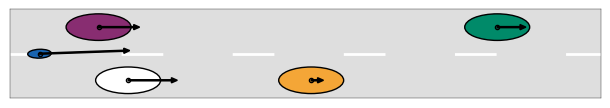

In [20]:
# --- Figure setup ---
%matplotlib inline
fig, ax = plt.subplots(figsize=(15 * cm, 3 * cm))
ax.set_aspect("equal")
ax.set_xlim(-8, 32)
ax.set_ylim(-3, 3)
ax.set_xticks([])
ax.set_yticks([])
# --- Background ---
ax.axhspan(-3, 3, facecolor=grey, zorder=-10)
ax.axhline(0, color="w", lw=2, ls=(0, (15, 25)), zorder=0)

# --- Objects: ellipses, points, arrows ---
objects = [
    (x_check, y_check, v_check, 0, s, w, 'w',),
    (x_f, -y_check, v_f, 0, s, w, dark_purple),
    (x_check_ell_hat, -y_check, v_ell_hat, 0, s, w, dark_teal),
    (x_check_ell_check, y_check, v_ell_check, 0, s, w, orange),
    (x_check_moto, y_check_moto, v_moto, theta_moto, s_moto, w_moto, dark_blue),
]

for x, y, v, theta, s_, w_, color in objects:
    ax.add_patch(Ellipse((x, y), 2 * s_, 2 * w_, angle=degrees(theta), ec="k", fc=color))
    ax.plot(x, y, "ko", mfc="none", markersize=3, zorder=150)
    ax.add_patch(
        FancyArrow(
            x,
            y,
            v * cos(theta),
            v * sin(theta),
            width=0.075,
            head_width=0.35,
            head_length=0.4,
            fc="k",
            ec="k",
            zorder=200,
            length_includes_head=True,
        )
    )

fig.tight_layout(pad=0)
# plt.savefig("./output/sketches/lc_scenario.pdf",
#    format="pdf",
#    transparent=True,
#    bbox_inches="tight",
#    pad_inches=0.01,)
plt.show()

In [21]:
constraints = []
phi_constraint = solve_phi_constraint(
    W,
    s,
    w,
    x_check,
    v_check,
    x_check_ell_check,
    v_ell_check,
    x_f,
    v_f,
    lam_f,
    v0_f,
    s0_f,
    phi_low=phi_min,
    phi_high=phi_max,
)
print(phi_constraint)
if phi_constraint:
    dt_constraint = compute_Dt_ell_check(phi_constraint, W, s, w, x_check, v_check, x_check_ell_check, v_ell_check)
    constraints.append((phi_constraint, dt_constraint))
constraints

0.24583729173273408


[(0.24583729173273408, 8.245559711454058)]

In [22]:
solutions = scan_phi_log(
    W,
    s,
    w,
    x_check,
    x_check_ell_hat,
    x_f,
    v_check,
    v_ell_hat,
    v_f,
    lam,
    v0,
    s0,
    lam_f,
    v0_f,
    s0_f,
    phi_min,
    phi_max,
    n_scan=5,
    xtol=1e-12,
)
solutions

[(0.1748160018448879, 12.38736332562682)]

In [23]:
# phi_min analysis
_, S_phi_min, Dx_phi_min = geom(phi_min, W)
Dt_0_phi_min = 2 * S_phi_min / (v0 + v_check)
Dt_max_phi_min = S_phi_min / v_check
# Dt_f_phi_min = closed_form(s_check_f, Dx_phi_min, v_f, lam_f, v0_f, s0_f)
Dt_f_phi_min = compute_Dt_f(
    phi_min,
    W,
    s,
    w,
    x_check,
    v_check,
    x_f,
    v_f,
    lam_f,
    v0_f,
    s0_f,
)
args_phi_min = (
    S_phi_min,
    Dx_phi_min,
    x_check,
    v_check,
    x_check_ell_hat,
    v_ell_hat,
    lam,
    v0,
    s0,
)
Dt_ell_phi_min = solve_nonlinear(*args_phi_min)
# phi_max analysis
_, S_phi_max, Dx_phi_max = geom(phi_max, W)
Dt_0_phi_max = 2 * S_phi_max / (v0 + v_check)
Dt_max_phi_max = S_phi_max / v_check
# Dt_f_phi_max = closed_form(s_check_f, Dx_phi_max, v_f, lam_f, v0_f, s0_f)
Dt_f_phi_max = compute_Dt_f(
    phi_max,
    W,
    s,
    w,
    x_check,
    v_check,
    x_f,
    v_f,
    lam_f,
    v0_f,
    s0_f,
)
args_phi_max = (
    S_phi_max,
    Dx_phi_max,
    x_check,
    v_check,
    x_check_ell_hat,
    v_ell_hat,
    lam,
    v0,
    s0,
)
Dt_ell_phi_max = solve_nonlinear(*args_phi_max)
constraint = None
if len(constraints) == 1:
    constraint = constraints[0]
# Decision logic based on number of solutions
if len(solutions) == 2:
    print("✅ 2 solutions exist.")
    phi_low, phi_high = solutions[0][0], solutions[-1][0]
    if constraint:
        # phi_star = loguniform.rvs(max(phi_low, constraint[0]), phi_high, random_state=rng)
        phi_star = rng.uniform(max(phi_low, constraint[0]), phi_high)
    else:
        # phi_star = loguniform.rvs(phi_low, phi_high, random_state=rng)
        phi_star = rng.uniform(phi_low, phi_high)

elif len(solutions) == 1:
    print("✅ 1 solution exists.")
    if Dt_f_phi_min > Dt_ell_phi_min:
        print("➡️ Choosing lower region.")
        if constraint:
            # phi_star = loguniform.rvs(max(phi_min, constraint[0]), solutions[0][0], random_state=rng)
            phi_star = rng.uniform(max(phi_min, constraint[0]), solutions[0][0])
        else:
            # phi_star = loguniform.rvs(phi_min, solutions[0][0], random_state=rng)
            phi_star = rng.uniform(phi_min, solutions[0][0])
    elif Dt_f_phi_min < Dt_ell_phi_min:
        print("➡️ Choosing upper region.")
        if constraint:
            print(solutions[0][0], constraint[0])
            # phi_star = loguniform.rvs(max(solutions[0][0], constraint[0]), phi_max, random_state=rng)
            phi_star = rng.uniform(max(solutions[0][0], constraint[0]), phi_max)
        else:
            # phi_star = loguniform.rvs(solutions[0][0], phi_max, random_state=rng)
            phi_star = rng.uniform(solutions[0][0], phi_max)
    else:
        print("➡️ Choosing solution.")
        phi_star = solutions[0][0]
else:
    if (Dt_f_phi_min > Dt_ell_phi_min) and (Dt_f_phi_max > Dt_ell_phi_max):
        print("✅ area between curves is feasible.")
        if constraint:
            # phi_star = loguniform.rvs(max(phi_min, constraint[0]), phi_max, random_state=rng)
            phi_star = rng.uniform(max(phi_min, constraint[0]), phi_max)
        else:
            # phi_star = loguniform.rvs(phi_min, phi_max, random_state=rng)
            phi_star = rng.uniform(phi_min, phi_max)
    else:
        print("❌ No valid solution found.")
        phi_star = None
if phi_star is not None:
    R, S, Dx = geom(phi_star, W)
    Dt_0 = 2 * S / (v0 + v_check)
    Dt_max = S / v_check
    # Solve both bounds
    # Dt_f = closed_form(s_check_f, Dx, v_f, lam_f, v0_f, s0_f)
    Dt_f = compute_Dt_f(phi_star, W, s, w, x_check, v_check, x_f, v_f, lam_f, v0_f, s0_f)
    args = (
        S,
        Dx,
        x_check,
        v_check,
        x_check_ell_hat,
        v_ell_hat,
        lam,
        v0,
        s0,
    )
    Dt_ell_hat = solve_nonlinear(*args)
    Dt_ell_check = compute_Dt_ell_check(phi_star, W, s, w, x_check, v_check, x_check_ell_check, v_ell_check)
    print("----------------------------------------------------")
    print(f"Dt_0={Dt_0:.2f}s  Dt_ell_hat={Dt_ell_hat:.2f}s  Dt_f={Dt_f:.2f}s  Dt_max={Dt_max:.2f}s")
    theta_star = -sign(y_check) * phi_star
    # Time duration of maneuver
    if Dt_ell_hat < Dt_max:
        if Dt_ell_hat < Dt_f:
            # Dt = loguniform.rvs(max(Dt_ell_hat, Dt_ell_check), Dt_f, random_state=rng)
            Dt = rng.uniform(max(Dt_ell_hat, Dt_ell_check), Dt_f)
        else:
            print("something weird happened")
            Dt = geometric_mean([Dt_ell_hat, Dt_f])
        # terminal x position
        x_hat = x_check + Dx
        # terminal y position
        y_hat = -y_check
        # terminal speed of LC vehicle
        v_hat = 2 * S / Dt - v_check
        # Constant acceleration
        a = (v_hat**2 - v_check**2) / (2 * S)
        # a = 2 * S / Dt**2 - 2 * v_check / Dt
        print(f"acceleration: {round(a,2)}, Dt: {round(Dt,1)}s")
    else:
        print(f"❌ No improvement (deceleration)")

✅ 1 solution exists.
➡️ Choosing upper region.
0.1748160018448879 0.24583729173273408
----------------------------------------------------
Dt_0=2.37s  Dt_ell_hat=3.16s  Dt_f=3.77s  Dt_max=5.17s
acceleration: 1.08, Dt: 3.4s


In [24]:
# Compute the full trajectory analytically
# if LC:
times, v_arr, theta_arr, x_arr, y_arr, t_star, v_star = sample_trajectory_closedform(
    v_check, x_check, y_check, a, R, Dt, theta_star, dt
)
PET_f, PET_ell_check, PET_ell_hat, (t_1, t_2f, t_1_ell_check, t_2_check, t_1_ell_hat, t_2_hat), details = pet(
    phi_star,
    W,
    s,
    w,
    a,
    x_check,
    y_check,
    v_check,
    x_f,
    v_f,
    x_check_ell_check,
    v_ell_check,
    x_check_ell_hat,
    v_ell_hat,
    theta_star,
    t_star,
    v_star,
    verbose=True,
)

t_1= 2.49s  t_2f= 3.33s  PET_f= 0.84s
t_1_ell_check=-3.50s  t_2_check= 1.37s  PET_ell_check= 4.88s
t_1_ell_hat=-7.14s  t_2_hat= 1.83s  PET_ell_hat= 8.97s


## Simulator

In [25]:
from scipy.stats import weibull_min

In [26]:
from pNeuma_simulator.gang.collision import collisions
from pNeuma_simulator.gang.particle import Particle
from pNeuma_simulator.gang.neighborhood import neighborhood
from pNeuma_simulator.contact_distance import ellipses
from pNeuma_simulator.utils import direction, projection, tangent_dist
from numba import jit
from numpy.linalg import norm
from numpy.typing import NDArray
from math import inf

In [27]:
@jit(nopython=True)
def infront(e_i, pos_i, pos_j):
    """
    Determines if a neighbor is in front of a given position.

    Args:
        e_i: The direction vector of the current position.
        pos_i: The current position.
        pos_j: The position of the neighbor.

    Returns:
        front: A boolean indicating if the neighbor is in front of the current position.
        e_i_j: The unit vector from the current position to the neighbor.
        s_i_j: The distance from the current position to the neighbor.
    """

    # Check if neighbor is in front
    r_i_j = pos_j - pos_i
    front = np.dot(e_i, r_i_j) > 0
    e_i_j = np.zeros(2)
    s_i_j = 0.0
    if front:
        # Distance from i to j
        s_i_j = float(norm(r_i_j))
        # Unit vector from i to j
        e_i_j = r_i_j / s_i_j
    return front, e_i_j, s_i_j

In [28]:
def ov(
    s: float | NDArray[np.floating], v: float | NDArray[np.floating], lam: float, v0: float, s0: float, T: float
) -> float | NDArray[np.floating]:
    x = v0 * (1 - np.exp((-lam / v0) * (s - s0 + T * v)))
    return x

In [29]:
prob = 0.03
p = prob * params.dt / 3
print(np.round(p, 6))

0.0001


In [30]:
232 / params.L

0.08055555555555556

In [31]:
p = 0.0001
seed = 1
time_duration = 20
brake_duration = 3
discounting = 0.6
n_cars = 58  # 232

In [ ]:
p = 0.0001
seed = 1
time_duration = 20  # 20  # 10
brake_duration = 3
discounting = 0.6
COUNT = int(time_duration * 60 / params.dt)
# skip = 10000
rng = np.random.default_rng(seed)
n_cars = 232  # 58  # 116  # 232
n_moto = 0
T_a = 0.7993
lam_a = 0.801
v0_a = 11.36
s0_a = 1.657
lamprime_a = 1.085
tauprime_a = 0.5969
tau_a = 2.098

sampler = PoissonDisc(
    n_cars, n_moto, cell=params.cell, L=params.L, W=params.cell * 3, k=params.k, clearance=params.clearance, rng=rng
)
samples, images = sampler.sample(rng)
agents = samples
brake_timer = np.zeros(len(agents), dtype=int)
brake_acc = np.zeros(len(agents))
l_agents = []
l_acc = []
T = np.repeat(T_a, 2 * n_cars)
lam = np.repeat(lam_a, 2 * n_cars)
tau = np.repeat(tau_a, 2 * n_cars)
v0 = np.repeat(v0_a, 2 * n_cars)
s0 = np.repeat(s0_a, 2 * n_cars)
lamprime = np.repeat(lamprime_a, 2 * n_cars)
tauprime = np.repeat(tauprime_a, 2 * n_cars)
for n, agent in enumerate(agents):
    # Reassign IDs
    agent.ID = n + 1
    agent.image = None
    agent.styles = None
    agent.tau = tau[n]
    agent.lam = lam[n]
    agent.v0 = v0[n]
    agent.s0 = s0[n]
for t in range(COUNT - 1):
    rand = rng.random(len(agents))
    ######################
    # Periodic boundary
    ######################
    images = []
    serial_agents = []
    for agent in agents:
        if agent.x < -(params.L / 2 - (params.d_max + agent.l)):
            image = deepcopy(agent)
            image.x += params.L
            images.append(image)
            agent.image = image
        elif agent.x > params.L / 2 - (params.d_max + agent.l):
            image = deepcopy(agent)
            image.x -= params.L
            images.append(image)
            agent.image = image
        # serial_agent = deepcopy(agent)
        # serial_agent.pos = serial_agent.pos.tolist()
        # serial_agent.vel = serial_agent.vel.tolist()
        # serial_agents.append(serial_agent.encode(t))
        serial_agents.append(
            {
                # "theta": agent.theta,
                "speed": agent.speed,
                "gap": agent.gap,
                # "ttc": agent.ttc,
                "pos": [agent.x, agent.y],
            }
        )
    l_agents.append(serial_agents)
    ##############################
    # Field of View analysis
    ##############################
    if t == 0:  # % skip == 0:
        for image in agents + images:
            cos_angle = -cos(image.theta)
            sin_angle = sin(image.theta)
            xc = params.xv - image.x
            yc = params.yv - image.y
            # https://stackoverflow.com/questions/37031356/
            xct = xc * cos_angle - yc * sin_angle
            yct = xc * sin_angle + yc * cos_angle
            rad = xct**2 / image.l**2 + yct**2 / image.w**2
            image.rad = rad
        matrices = []
        origins = []
        for agent in agents:
            matrix = np.zeros(params.shape)
            # top/bottom boundaries
            matrix[[0, -1], :] = 1
            for image in agents + images:
                if image.ID != agent.ID:
                    assert image.rad is not None
                    matrix[image.rad < 1] = image.ID
            matrices.append(matrix)
            assert agent.rad is not None
            origin = unravel_index(agent.rad.argmin(), params.shape)
            origins.append(origin)
        tuples = []
        for i, j in zip(matrices, origins):
            shadowcast = shadowcasting(i, j, params.grid, params.L, params.d_max)
            tuples.append(shadowcast)
        for n, agent in enumerate(agents):
            assert tuples is not None
            interactions = tuples[n]
            agent.interactions = interactions.tolist()
    ################################
    # Dynamics
    ################################
    l_theta = []
    l_speed = []
    l_gap = []
    l_ttc = []
    for agent in agents:
        l_speed.append(agent.speed)
        theta_i = agent.theta
        l_theta.append(theta_i)
        # Semiaxis dimensions of i
        l_i, w_i = agent.l, agent.w
        # Absolute position of i
        pos_i = agent.pos
        x_i, y_i = pos_i
        interactions = agent.interactions
        if len(interactions) > 0:
            gaps = []
            neighbors = neighborhood(agent, agents)
            # Direction vector and its normal
            e_i, e_i_n = direction(theta_i)
            front_neighbors = []
            for neighbor in neighbors:
                # Semiaxis dimensions of j
                l_j, w_j = neighbor.l, neighbor.w
                # Absolute position of j
                pos_j = neighbor.pos
                x_j, y_j = pos_j
                # Direction of j
                theta_j = neighbor.theta
                # Check if neighbor is in front
                front, e_i_j, s_i_j = infront(e_i, pos_i, pos_j)
                if front:
                    front_neighbors.append(neighbor)
                    # Distance from tangent parallel to i
                    k_h = tangent_dist(theta_j, theta_i, l_j, w_j)
                    proj = projection(e_i_n, e_i_j, s_i_j)
                    # This is extremely important!!!
                    if proj <= params.scaling * w_i + k_h:
                        # Distance of closest approach between i and j
                        if proj == 0:
                            min_d = l_i + l_j
                        else:
                            min_d = ellipses(
                                l_j,
                                w_j,
                                l_i,
                                w_i,
                                x_j,
                                y_j,
                                x_i,
                                y_i,
                                theta_j,
                                theta_i,
                            )
                        gap = s_i_j - min_d
                    else:
                        gap = inf
                else:
                    gap = inf
                gaps.append(gap)
            if np.isfinite(gaps).sum() > 0:
                leader = neighbors[np.argmin(gaps)]
                gap = min(gaps)
                agent.leader = leader.ID
                agent.gap = gap
                # actual time to collision
                assert agent.speed is not None
                ttc = collisions(agent, agent.speed, 0, [leader])
                agent.ttc = ttc
            else:
                agent.leader = None
                agent.gap = params.d_max
        else:
            agent.leader = None
            agent.gap = params.d_max
        assert agent.gap is not None
        if agent.gap <= 0:
            print("Accident occurred")
        # Retrieve inverse ttc
        if agent.ttc is None:
            ttc = -1
        else:
            ttc = agent.ttc
        l_ttc.append(ttc)
        l_gap.append(agent.gap)
    # Stochastic component
    ttc = np.array(l_ttc)
    gaps = np.array(l_gap)
    DeltaV = gaps / ttc
    V = np.array(l_speed)
    OV = np.array(ov(gaps, V, lam[0], v0[0], s0[0], T[0]))
    # --- deterministic acceleration ---
    acc_det = (OV - V) / tau - (np.maximum(0, DeltaV) / tauprime) * (np.exp(-(lamprime / v0) * (gaps - s0 + T * V)))
    # --------------------------------------------------
    # 1. Decrement timers from previous timestep
    # --------------------------------------------------
    brake_timer[brake_timer > 0] -= 1
    # --------------------------------------------------
    # 2. Trigger new braking events
    # --------------------------------------------------
    new_brake = (brake_timer == 0) & (rand < p)
    if np.any(new_brake):
        idx = np.where(new_brake)[0]
        durations = np.repeat(brake_duration, len(idx))
        brake_timer[idx] = np.ceil(durations / params.dt).astype(int)
        brake_acc[idx] = (discounting * OV[idx] - V[idx]) / tau[idx] - (
            (np.maximum(0, DeltaV)[idx]) / tauprime[idx]
        ) * (np.exp(-(lamprime[idx] / v0[idx]) * (gaps[idx] - s0[idx] + T[idx] * V[idx])))
        l_acc.extend(brake_acc[idx])
    # --------------------------------------------------
    # 3. Recompute active braking AFTER timer update
    # --------------------------------------------------
    braking = brake_timer > 0
    # --------------------------------------------------
    # 4. Compute acceleration
    # --------------------------------------------------
    acc = np.where(braking, brake_acc, acc_det)
    # --------------------------------------------------
    # 5. Update velocity
    # --------------------------------------------------
    new_V = np.maximum(V + acc * params.dt, 0.0)
    ##################################
    # Advance the simulation
    ##################################
    for n, agent in enumerate(agents):
        agent.advance(params.dt, new_V[n])
        agent.image = None
        agent.trajectory = None

In [ ]:
import json

In [ ]:
# n_cars, seed  # = 232, 15

In [ ]:
path = f"./output/sketches/nasch_INM_{seed}_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}.jsonl"

In [36]:
with open(
    f"./output/sketches/nasch_INM_{seed}_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}.jsonl", "w"
) as outfile:
    json.dump(l_agents, outfile)
    outfile.write("\n")

In [38]:
with open(path, "r") as infile:
    l_agents = json.load(infile)
l_agents[10][0]

{'speed': 0.1931311126614846,
 'gap': 8.013793103448256,
 'pos': [-359.9893326867571, -1.8]}

In [39]:
# fig, ax = plt.subplots(figsize=(6 * params.cm, 4 * params.cm), dpi=200)
# _ = plt.hist(array(l_acc), bins="scott")
# plt.tight_layout(pad=0)

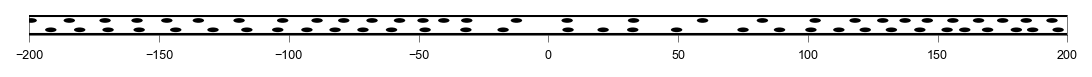

In [37]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(18 * cm, 2 * cm), dpi=150)
setattr(fig.canvas, "header_visible", False)
ax.set_aspect("equal")
for sample in samples:
    sample.styles = {"ec": "none", "fc": "k", "fill": True, "lw": 0.6}
    sample.draw(ax)
for image in images:
    image.styles = {"ec": "k", "fill": False, "lw": 0.5, "ls": "--"}
    image.draw(ax)
for agent in agents:
    if agent.ID==13:
        agent.styles = {"ec": "b", "fill": True, "lw": 1, "ls": "-"}
        agent.draw(ax)
        neighbors = neighborhood(agent, agents)
        for neighbor in neighbors:
            neighbor.styles = {"ec": "r", "fill": True, "lw": 1, "ls": "-"}
            neighbor.draw(ax)
ax.hlines(
    [-params.lane, params.lane],
    xmin=-L / 2,
    xmax=L / 2,
    color="k",
    ls="-",
    lw=1,
)
ax.set_yticks([])
ax.set_xlim(-200, 200)
fig.tight_layout(pad=0)

In [32]:
from matplotlib.ticker import FuncFormatter

In [33]:
from palettable.colorbrewer.diverging import RdYlGn_11  # type: ignore

cmap = RdYlGn_11.mpl_colormap

In [34]:
L = params.L
L

2880

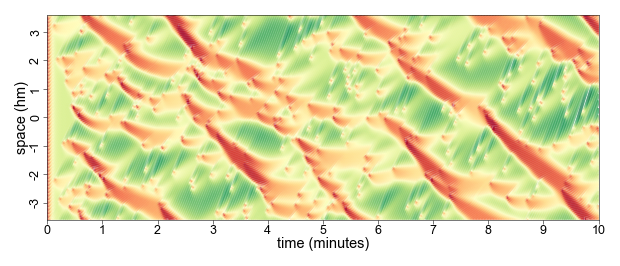

In [41]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(10 * cm, 4 * cm), dpi=150)
setattr(fig.canvas, "header_visible", False)
printline = False
lanes = [1]

# --------- PARAMETERS ----------
v_line = -0.044
l_x0 = [0. * L, 0. * L]
l_c = ['k', 'k']
step = 10  # ← sample every Nth time point
# compute global velocity limits once
all_v = [l_agents[t][n]["speed"] for t in range(0, len(l_agents), step) for n in range(2 * n_cars)]

norm = Normalize(np.min(all_v), np.max(all_v))
# ------------------------------

for lane_idx, lane_sign in enumerate(lanes):

    for n in range(2 * n_cars):
        l_pos = []
        l_vel = []
        prev = None

        # ---- SAMPLE IN TIME (correct way) ----
        for t in range(0, len(l_agents), step):
            group = l_agents[t]

            if group[n]["pos"][1] * lane_sign > 0:
                x = group[n]["pos"][0]
                z = group[n]["speed"]

                if prev is not None and abs(x - prev) > 0.5 * L:
                    l_pos.append(np.nan)
                    l_vel.append(np.nan)

                l_pos.append(x)
                l_vel.append(z)
                prev = x
        # --------------------------------------

        # ---------- COLORED LINE (respect NaNs) ----------
        t_axis = np.arange(len(l_pos)) * step * params.dt / 60  # minutes
        start = 0
        for i in range(len(l_pos) + 1):
            if i == len(l_pos) or np.isnan(l_pos[i]):
                if i - start > 1:
                    colored_line(
                        t_axis[start:i],
                        l_pos[start:i],
                        l_vel[start:i],
                        ax=ax,
                        cmap=cmap,
                        norm=norm,
                        #lw=1.5,
                        zorder=2,
                        clip_on=True,
                    )
                start = i + 1
        # -------------------------------------------------

    # --------- PERIODIC TILTED LINE (sampled) ----------
    line = []
    prev = None
    for t in range(0, len(l_agents), step):
        x = (l_x0[lane_idx] + v_line * t + L / 2) % L - L / 2
        if prev is not None and abs(x - prev) > 0.5 * L:
            line.append(np.nan)
        line.append(x)
        prev = x

    t_axis = np.arange(len(line)) * step * params.dt / 60 
    if printline:
        ax.plot(t_axis, line, c=l_c[lane_idx], lw=.1,ls='-')

    #ax.set_xlim(0, len(l_agents) / step)
    ax.set_xlim(0,10)
    ax.set_xticks(arange(0, 11, 1))
    ax.set_ylim(-L / 2, L / 2)
ax.set_ylabel("space (hm)", labelpad=0.5)
ax.set_xlabel("time (minutes)", labelpad=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y/100:g}"))
ax.tick_params(axis="y", length=2, pad=.5, labelrotation=90)
ax.tick_params(axis="x", length=2, pad=.5)
plt.setp(ax.get_yticklabels(), ha="right", va="center")
plt.tight_layout(pad=0)
save = False
if save:
    plt.savefig(f"./output/sketches/nasch_INM_{seed}_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.01,)
plt.show()

In [42]:
speeds = []
gaps = []
l_ttc = []
for t in range(len(l_agents) - 1):
    if t > 10:
        gaps.append(l_agents[t][0]["gap"])
        speeds.append(l_agents[t][0]["speed"])
        # ttc = l_agents[t][0]["ttc"]
        # for agent in l_agents[t]:
        #    ttc = agent["ttc"]
        #    if ttc:
        #        l_ttc.append(ttc)
l_ttc = array(l_ttc)
ttc_data = array(l_ttc).astype(float)
len(speeds)

59987

In [43]:
def ov3(p, s):
    lam, v0, s0 = p
    return v0 - v0 * np.exp((-lam / v0) * (s - s0))


def ov4(p, s, v):
    lam, v0, s0, T = p
    return v0 * (1 - np.exp(-(lam / v0) * (s - s0 + T * v)))

In [44]:
from scipy.special import lambertw

l = 4.4  # vehicle length (m)
L = 8 * 360  # road length (m)
# n_cars = 29
T_a = 0.7993
lam_a = 0.801
v0_a = 11.36
s0_a = 1.657
lamprime_a = 1.085
tauprime_a = 0.5969
tau_a = 2.098

# Step 1: Compute dimensionless constant C
C = lam_a * (s0_a + l) / v0_a + 1

# Step 2: Analytical solution using Lambert W lower branch (k=-1)
u = -1 / lambertw(-np.exp(-C), k=-1)  # u = 1 - vc/v0

# Step 3: Critical speed
v_c = v0_a * (1 - u.real)

# Step 4: Critical spacing
s_c = s0_a - T_a * v_c - (v0_a / lam_a) * np.log(1 - v_c / v0_a)
h_c = s0_a + l - T_a * v_c - (v0_a / lam_a) * np.log(1 - v_c / v0_a)

# Step 5: Critical density (vehicles per meter)
k_c = 1 / h_c

# Step 6: Number of vehicles on the road
N_c = k_c * L

# Step 7: Critical occupancy (fraction of road filled)
occupancy_c = k_c * l

# Print results
print(f"Critical speed vc = {v_c:.3f} m/s ({v_c*3.6:.1f} km/h)")
print(f"Critical gross spacing hc = {h_c:.3f} m")
print(f"Critical netto spacing sc = {s_c:.3f} m")
print(f"Critical density kc = {k_c:.3f} veh/m ({k_c*1000:.1f} veh/km)")
print(f"Number of vehicles at capacity Nc = {N_c:.1f}")
print(f"Critical occupancy = {occupancy_c:.3f} ({occupancy_c*100:.1f}%)")

Critical speed vc = 6.262 m/s (22.5 km/h)
Critical gross spacing hc = 12.415 m
Critical netto spacing sc = 8.015 m
Critical density kc = 0.081 veh/m (80.5 veh/km)
Number of vehicles at capacity Nc = 232.0
Critical occupancy = 0.354 (35.4%)


In [45]:
k_c, np.round(N_c) / L

(0.08054516631617306, 0.08055555555555556)

In [46]:
# Capacity point: maximum flow
q_c = v_c / h_c  # vehicles per second
q_c_kmh = q_c * 3600  # vehicles per hour

print(f"Critical flow (capacity) qc = {q_c:.3f} veh/s ({q_c_kmh:.1f} veh/h)")

Critical flow (capacity) qc = 0.504 veh/s (1815.8 veh/h)


In [47]:
wave_speed = -q_c_kmh / (1000 / (l + s0_a) - k_c * 1000)
wave_speed = v_c * (s0_a + l) / (T_a * v_c + v0_a / lam_a * np.log(1 - v_c / v0_a)) * factor
wave_speed

-21.474739939301255

In [48]:
T_max = -v0_a / (lam_a * v_c) * np.log(1 - v_c / v0_a)
T_max

1.8146883149054562

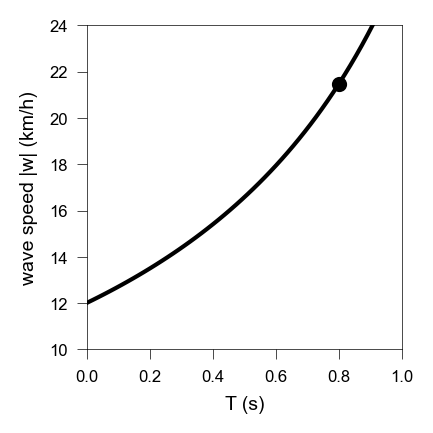

In [49]:
T_values = np.linspace(0, T_a + 1, 100)  # T gap from 0.5s to 2s
w_values = -(v_c * (s0_a + l)) / (T_values * v_c + (v0_a / lam_a) * np.log(1 - v_c / v0_a)) * factor
fig, ax = plt.subplots(figsize=(5 * params.cm, 5 * params.cm), dpi=200)
ax.axvline(T_max)
plt.plot(T_values, w_values, c="k")
ax.scatter(T_a, -wave_speed, c="k", zorder=100, s=20, label="data")
plt.xlabel("T (s)")
plt.ylabel("wave speed |w| (km/h)")
plt.xlim(0, min([T_max, 1]))
plt.ylim(10, 24)
plt.tight_layout(pad=0)
plt.show()

In [50]:
popt = lam_a, v0_a, s0_a, T_a
s_plot = np.linspace(popt[-2], 100, 10000)
length = 2 * params.car_l
# for plotting only: evaluate 4-param using its own prediction
# fixed-point iteration (fast, no root finder)
y3_plot = ov3(popt[:3], s_plot)
y4_plot = np.zeros_like(s_plot)
for _ in range(int(1e4)):
    y4_plot = ov4(popt, s_plot, y4_plot)

k3 = 1000 / (s_plot + length)
o3 = length / (s_plot + length)
v3 = y3_plot * params.factor
q3 = k3 * v3
v3 = np.append(v3, popt[1] * params.factor)
k3 = np.append(k3, 0)
o3 = np.append(o3, 0)
q3 = np.append(q3, 0)

k4 = 1000 / (s_plot + length)
o4 = length / (s_plot + length)
v4 = y4_plot * params.factor
q4 = k4 * v4
v4 = np.append(v4, v0 * params.factor)
k4 = np.append(k4, 0)
o4 = np.append(o4, 0)
q4 = np.append(q4, 0)

In [43]:
from palettable.colorbrewer.diverging import Spectral_8  # type: ignore
from palettable.colorbrewer.sequential import GnBu_9  # type: ignore

cmap_seq = GnBu_9.mpl_colormap
cmap = Spectral_8.mpl_colormap  # type: ignore

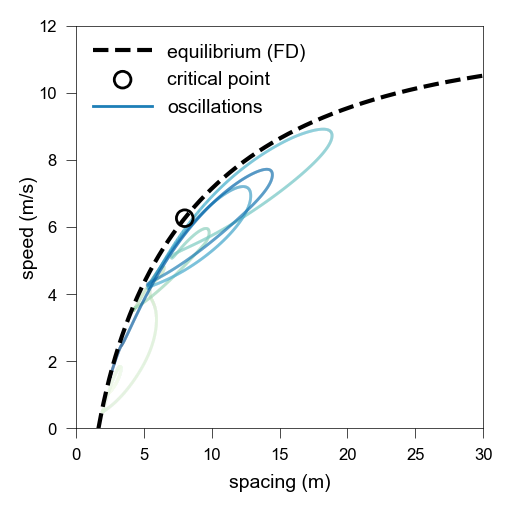

In [52]:
from matplotlib.lines import Line2D
%matplotlib inline
fig, ax = plt.subplots(figsize=(6 * params.cm, 6 * params.cm), dpi=200)
support = arange(0, 10, 0.01)
eq_handle, = plt.plot(
    s_plot,
    y4_plot,
    label="equilibrium (FD)",
    clip_on=True,
    zorder=10,
    c="k",
    ls="--",
)
cp = ax.scatter(s_c, v_c, ec="k", fc="none", lw=1, zorder=50,label='critical point')
i0 = 50000
x_osc = np.asarray(gaps)[i0:]
y_osc = np.asarray(speeds)[i0:]
t_osc = np.arange(i0, i0 + len(x_osc))  # use your actual time array here if you have one
lc = colored_line(
    x_osc,
    y_osc,
    t_osc,
    ax,
    cmap=cmap_seq,
    linewidth=1,
    clip_on=False,
    zorder=-1,
)
osc_handle = Line2D(
    [], [],
    lw=1,
    color=cmap_seq(0.8),
    label="oscillations",
)
ax.legend(
    handles=[eq_handle, cp, osc_handle, ],
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=2,
)
ax.set_xlim(0, 30)
ax.set_ylim(0, 12)
ax.set_ylabel("speed (m/s)", labelpad=0)
ax.set_xlabel("spacing (m)")
plt.tight_layout(pad=0)
plt.show()

In [33]:
# fig, ax = plt.subplots(figsize=(6 * params.cm, 6 * params.cm), dpi=200)
# plt.plot(o3, q3 / 1000, clip_on=True, zorder=10, label="NNM", c=dark_blue, ls="--")
# plt.plot(o4, q4 / 1000, clip_on=True, zorder=12, label="INM", c=dark_teal, ls="--")
# plt.xlim(0, 0.9)
# plt.ylim(0, 3.5)
# ax.legend(
#    frameon=False,
#    handlelength=3,
#    fontsize=7,
#    loc=0,
# )
# ax.axvline(occupancy_c, c="k", ls=":", lw=1)
# ax.scatter(occupancy_c, q_c_kmh / 1000, ec="k", fc="none", lw=1, zorder=50)
# ax.set_ylabel("flow (1000/h)", labelpad=0)
# ax.set_xlabel("occupancy")
# plt.tight_layout(pad=0)
# plt.show()

# Finite size scaling analysis

In [45]:
import json

In [46]:
n_cars = 232
seed = 2

In [47]:
n_cars, seed  # = 58, 85

(232, 2)

In [43]:
path = f"./output/sketches/nasch_INM_{seed}_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}.jsonl"

In [44]:
with open(path, "r") as infile:
    l_agents = json.load(infile)
l_agents[10][0]

{'speed': 0.1931311126614874,
 'gap': 8.01379310344837,
 'pos': [-1439.9893326867573, -1.8]}

In [48]:
n_steps = len(l_agents)
positions = np.zeros((n_steps, n_cars))
velocities = np.zeros((n_steps, n_cars))
spacings = np.zeros((n_steps, n_cars))
timestamps = np.arange(0, n_steps) * dt
for t in range(n_steps):
    idx = 0
    for n in range(2 * n_cars):
        x_a = l_agents[t][n]["pos"][0]
        y_a = l_agents[t][n]["pos"][1]
        v_a = l_agents[t][n]["speed"]
        s_a = l_agents[t][n]["gap"]
        if y_a > 0:
            positions[t, idx] = x_a
            velocities[t, idx] = v_a
            spacings[t, idx] = s_a
            idx += 1
    # sanity check: make sure we filled exactly n_cars per row
    if idx != n_cars:
        raise ValueError(f"Expected {n_cars} vehicles at t={t}, got {idx}")

In [49]:
def eulerian_surface_from_passages(positions, L, dx=7.0):
    T, N = positions.shape
    M = int(np.ceil(L / dx))

    h = np.zeros((T, M), dtype=np.int32)

    prev_cells = np.floor(np.mod(positions[0], L) / dx).astype(int) % M

    for t in range(1, T):
        curr_cells = np.floor(np.mod(positions[t], L) / dx).astype(int) % M

        h[t] = h[t - 1]

        for j in range(N):
            c0 = prev_cells[j]
            c1 = curr_cells[j]
            crossed = (c1 - c0) % M

            for k in range(1, crossed + 1):
                h[t, (c0 + k) % M] += 1

        prev_cells = curr_cells

    x = (np.arange(M) + 0.5) * dx
    x = np.minimum(x, L - 0.5 * dx)
    return x, h

In [50]:
x, h = eulerian_surface_from_passages(
    positions=positions,
    L=params.L,
    dx=9,
)

In [51]:
N = h

In [52]:
# _ = plt.imshow(N, aspect="auto", cmap=Spectral_8.mpl_colormap, origin="lower")

In [53]:
# _ = plt.imshow(spacings, aspect="auto", cmap=Spectral_8.mpl_colormap, origin="lower")

In [54]:
from palettable.colorbrewer.diverging import Spectral_8  # type: ignore
from palettable.colorbrewer.sequential import GnBu_9, Blues_9  # type: ignore

cmap = Spectral_8.mpl_colormap  # type: ignore

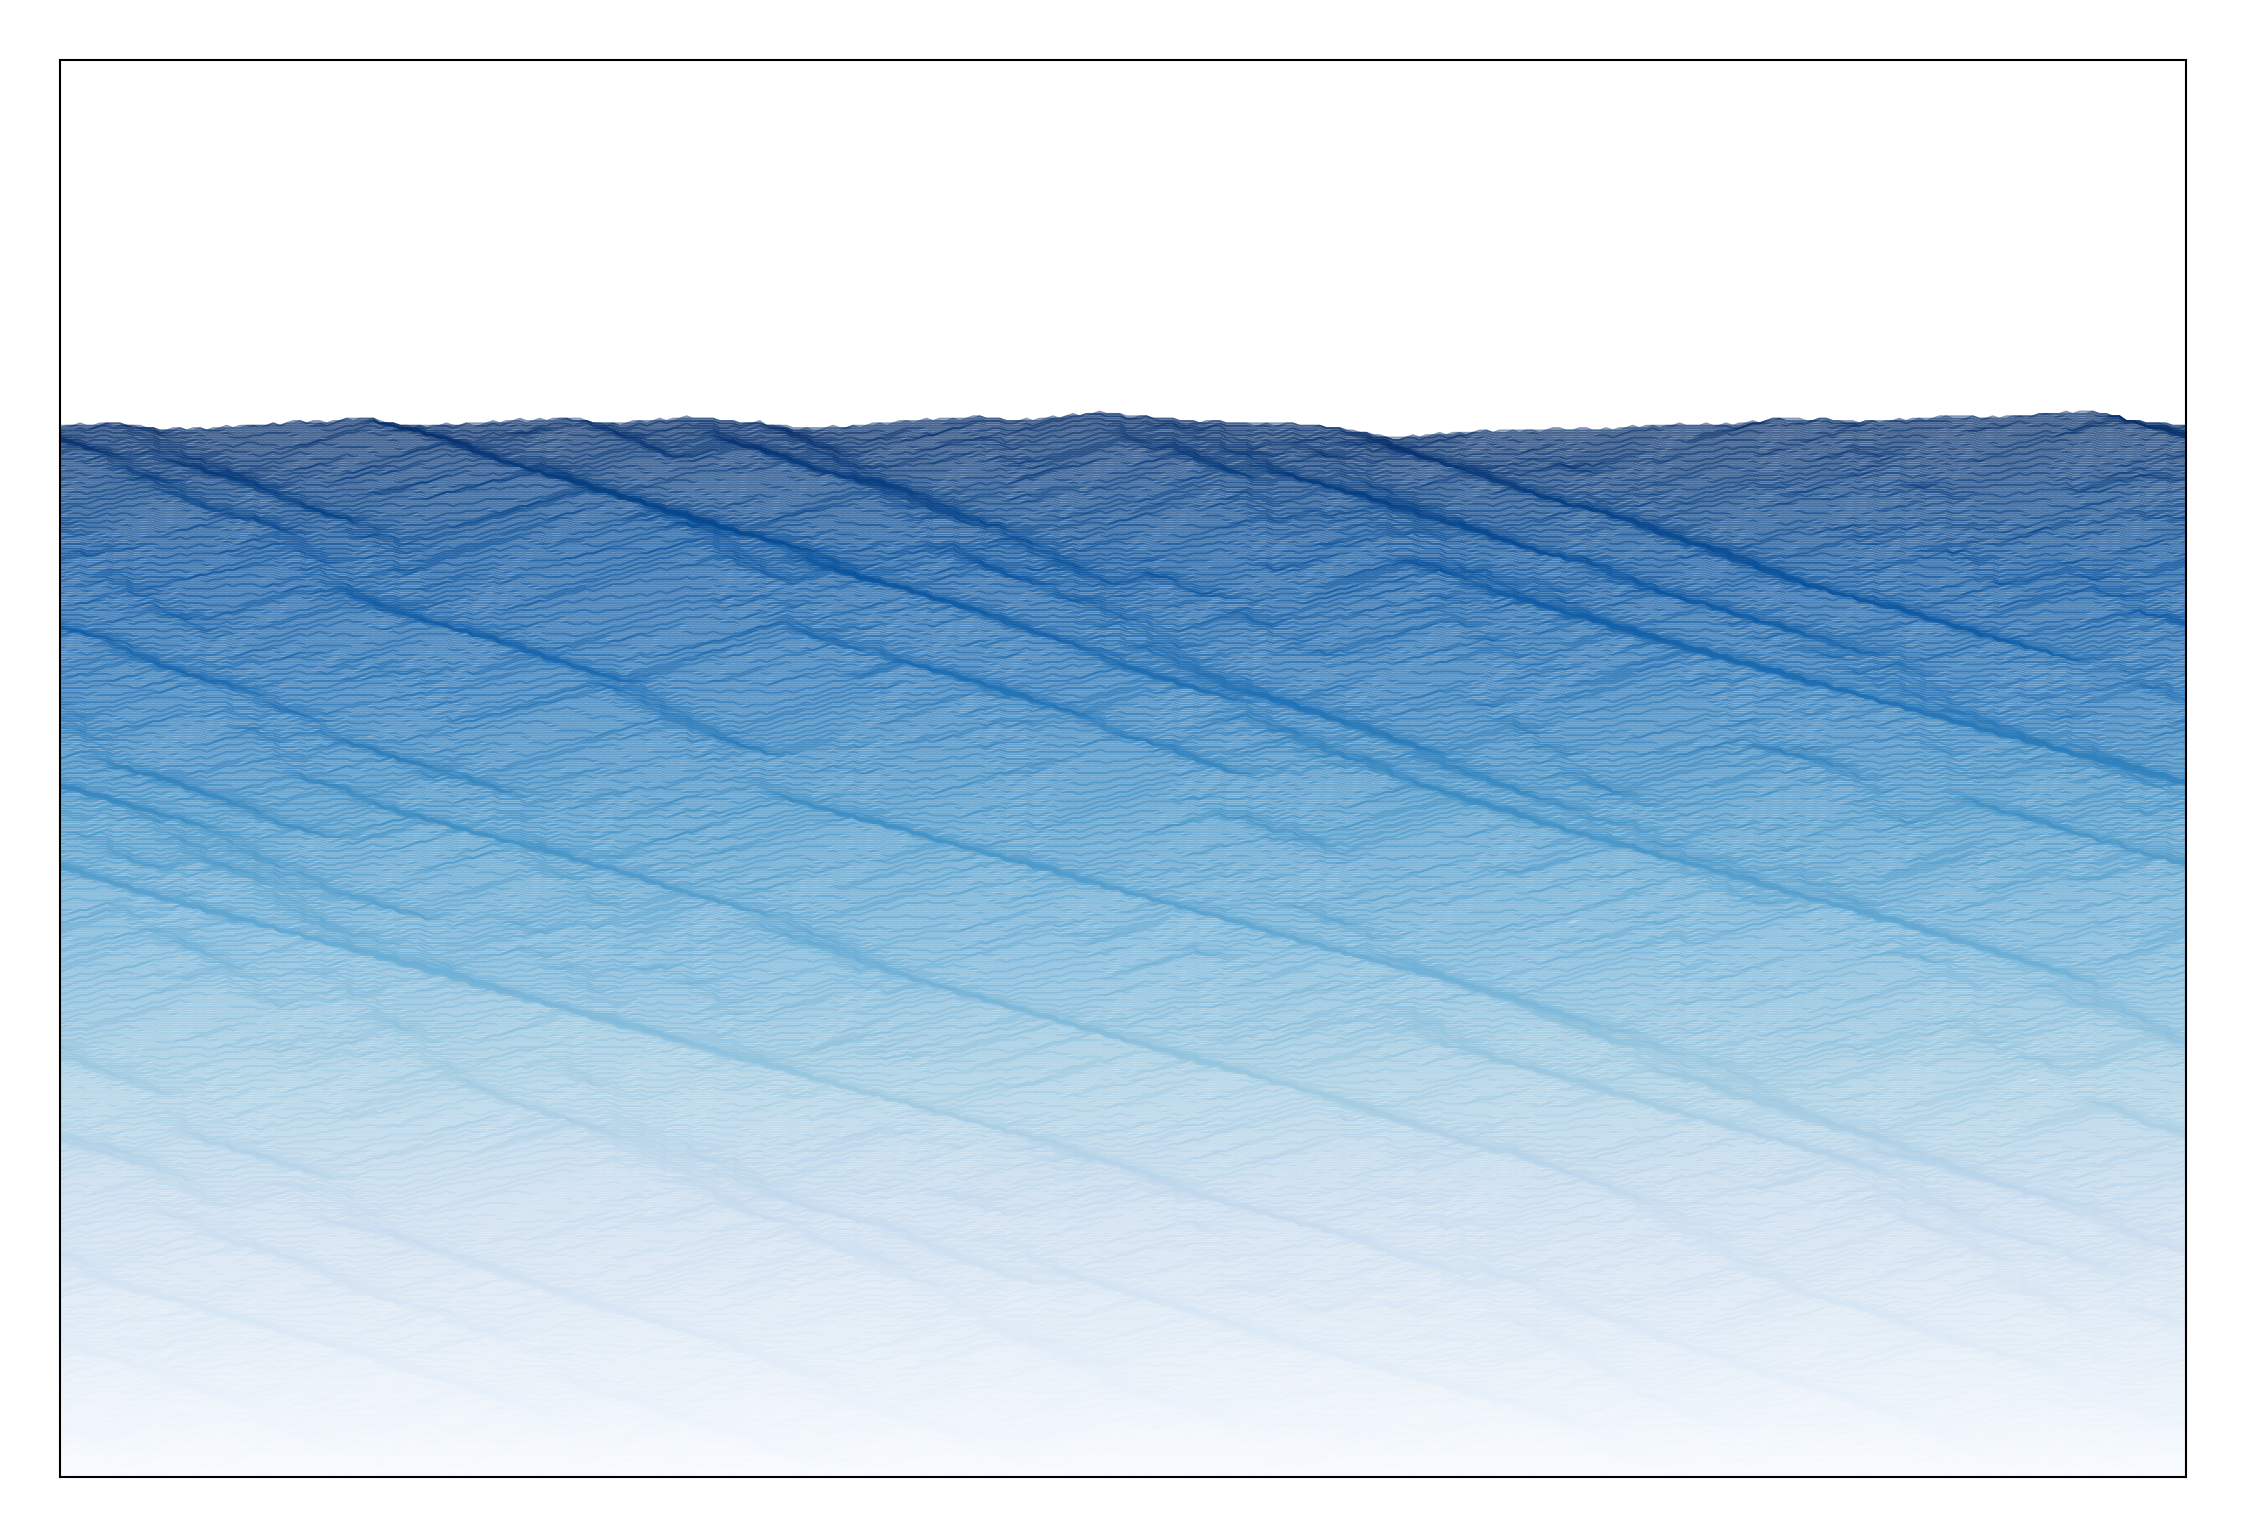

In [55]:
# Example parameters
indices = np.arange(0, N.shape[0], 100)  # same as your slicing
colors = Blues_9.mpl_colormap(np.linspace(0, 1, len(indices)))  # gradient across indices
fig, ax = plt.subplots(figsize=(9 * params.cm, 6 * params.cm), dpi=600)
for i, idx in enumerate(indices):
    ax.plot(N[idx, :], color=colors[i], lw=0.25, alpha=0.5)
ax.set_xlim(0, N.shape[1] - 1)
ax.set_ylim(0, 600)
# Remove all ticks and numbers
ax.set_xticks([])  # remove x-axis ticks
ax.set_yticks([])  # remove y-axis ticks
ax.set_xticklabels([])  # remove x-axis labels
ax.set_yticklabels([])  # remove y-axis labels
plt.tight_layout(pad=0)
plt.show()

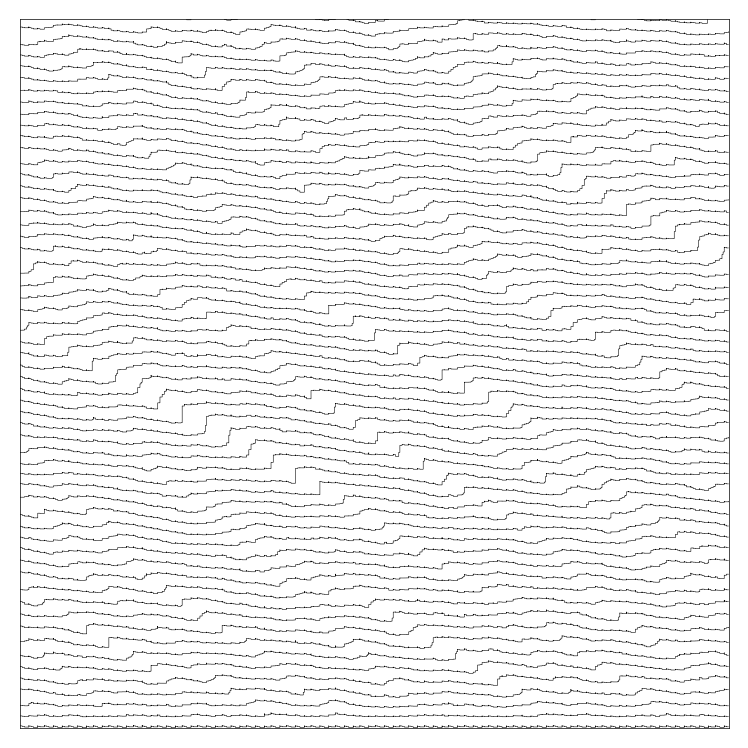

In [56]:
fig, ax = plt.subplots(figsize=(9 * params.cm, 9 * params.cm), dpi=200)

# Assuming N_fluct is a 2D array
# Create coordinate grids for plotting
y = np.arange(N.shape[0])
x = np.arange(N.shape[1])
X, Y = np.meshgrid(x, y)

# Plot black contours
# Number of contour levels you want
num_contours = 60  # <-- change this to control number of contours

# Plot contours
contours = ax.contour(
    X,
    Y,
    N,  # your array (negated if needed)
    levels=num_contours,  # number of contour levels
    colors="black",  # black lines
    linewidths=0.2,  # line width
)
# ax.set_title("Contour Plot of N_fluct")
# Remove all ticks and numbers
ax.set_xticks([])  # remove x-axis ticks
ax.set_yticks([])  # remove y-axis ticks
ax.set_xticklabels([])  # remove x-axis labels
ax.set_yticklabels([])  # remove y-axis labels
plt.tight_layout(pad=0)
plt.show()

In [57]:
np.shape(N)

(119999, 320)

In [58]:
def interface_width_series(H):
    H_mean = np.mean(H, axis=1, keepdims=True)  # mean over spatial indices
    W_series = np.sqrt(np.mean((H - H_mean) ** 2, axis=1))
    return W_series

In [59]:
W_series = interface_width_series(N)

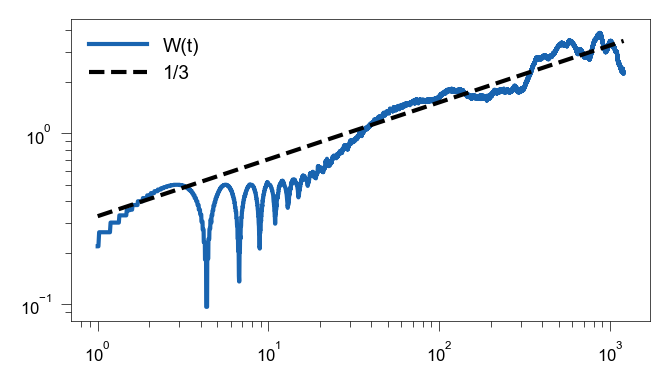

In [60]:
# Assume W_series is already computed and has shape (T,)
start = 100
W_late = W_series[start:]  # take late-time part
t = np.arange(0, len(W_series)) * dt
t_late = t[start:]
# t = np.arange(start, start + len(W_late))  # corresponding time steps

fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=200)
ax.set_aspect("equal")
plt.loglog(t_late, W_late, label="W(t)", c=dark_blue)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t_late))
ref_line = np.exp(logA) * t_late ** (1 / 3)
plt.loglog(t_late, ref_line, "--", label="1/3", c="k")

# ax.yaxis.set_minor_formatter(
#    LogFormatterSciNotation(
#        base=10,
#        labelOnlyBase=False,
#        minor_thresholds=(np.inf, np.inf),
#    )
# )

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

In [69]:
seed, n_cars

(55, 58)

In [ ]:
np.save(f"./output/sketches/nasch_INM_{seed}_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy", W_series)
seed

55

In [ ]:
n_cars = 232
W_series_L1 = np.load(f"./output/sketches/nasch_INM_1_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R1 = np.load(f"./output/sketches/nasch_INM_1_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L2 = np.load(f"./output/sketches/nasch_INM_2_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R2 = np.load(f"./output/sketches/nasch_INM_2_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L3 = np.load(f"./output/sketches/nasch_INM_3_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R3 = np.load(f"./output/sketches/nasch_INM_3_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L4 = np.load(f"./output/sketches/nasch_INM_4_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R4 = np.load(f"./output/sketches/nasch_INM_4_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L5 = np.load(f"./output/sketches/nasch_INM_5_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R5 = np.load(f"./output/sketches/nasch_INM_5_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L6 = np.load(f"./output/sketches/nasch_INM_6_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R6 = np.load(f"./output/sketches/nasch_INM_6_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L7 = np.load(f"./output/sketches/nasch_INM_7_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R7 = np.load(f"./output/sketches/nasch_INM_7_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L8 = np.load(f"./output/sketches/nasch_INM_8_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R8 = np.load(f"./output/sketches/nasch_INM_8_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L9 = np.load(f"./output/sketches/nasch_INM_9_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R9 = np.load(f"./output/sketches/nasch_INM_9_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L10 = np.load(f"./output/sketches/nasch_INM_10_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R10 = np.load(f"./output/sketches/nasch_INM_10_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L11 = np.load(f"./output/sketches/nasch_INM_11_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R11 = np.load(f"./output/sketches/nasch_INM_11_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L12 = np.load(f"./output/sketches/nasch_INM_12_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R12 = np.load(f"./output/sketches/nasch_INM_12_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L13 = np.load(f"./output/sketches/nasch_INM_13_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R13 = np.load(f"./output/sketches/nasch_INM_13_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L14 = np.load(f"./output/sketches/nasch_INM_14_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R14 = np.load(f"./output/sketches/nasch_INM_14_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L15 = np.load(f"./output/sketches/nasch_INM_15_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R15 = np.load(f"./output/sketches/nasch_INM_15_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L100 = np.load(
    f"./output/sketches/nasch_INM_100_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R100 = np.load(
    f"./output/sketches/nasch_INM_100_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_average = np.mean(
    [
        W_series_L1,
        W_series_R1,
        W_series_L2,
        W_series_R2,
        W_series_L3,
        W_series_R3,
        W_series_L4,
        W_series_R4,
        W_series_L5,
        W_series_R5,
        W_series_L6,
        W_series_R6,
        W_series_L7,
        W_series_R7,
        W_series_L8,
        W_series_R8,
        W_series_L9,
        W_series_R9,
        W_series_L10,
        W_series_R10,
        W_series_L11,
        W_series_R11,
        W_series_L12,
        W_series_R12,
        W_series_L13,
        W_series_R13,
        W_series_L14,
        W_series_R14,
        W_series_L15,
        W_series_R15,
    ],
    axis=0,
)
W_average_45 = np.mean(
    [W_series_L100, W_series_R100],
    axis=0,
)

n_cars = 58
W_series_L10_58 = np.load(
    f"./output/sketches/nasch_INM_10_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R10_58 = np.load(
    f"./output/sketches/nasch_INM_10_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L20_58 = np.load(
    f"./output/sketches/nasch_INM_20_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R20_58 = np.load(
    f"./output/sketches/nasch_INM_20_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L30_58 = np.load(
    f"./output/sketches/nasch_INM_30_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R30_58 = np.load(
    f"./output/sketches/nasch_INM_30_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L40_58 = np.load(
    f"./output/sketches/nasch_INM_40_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R40_58 = np.load(
    f"./output/sketches/nasch_INM_40_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L50_58 = np.load(
    f"./output/sketches/nasch_INM_50_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R50_58 = np.load(
    f"./output/sketches/nasch_INM_50_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L55_58 = np.load(
    f"./output/sketches/nasch_INM_55_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R55_58 = np.load(
    f"./output/sketches/nasch_INM_55_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L60_58 = np.load(
    f"./output/sketches/nasch_INM_60_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R60_58 = np.load(
    f"./output/sketches/nasch_INM_60_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L65_58 = np.load(
    f"./output/sketches/nasch_INM_65_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R65_58 = np.load(
    f"./output/sketches/nasch_INM_65_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L70_58 = np.load(
    f"./output/sketches/nasch_INM_70_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R70_58 = np.load(
    f"./output/sketches/nasch_INM_70_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L75_58 = np.load(
    f"./output/sketches/nasch_INM_75_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R75_58 = np.load(
    f"./output/sketches/nasch_INM_75_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L80_58 = np.load(
    f"./output/sketches/nasch_INM_80_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R80_58 = np.load(
    f"./output/sketches/nasch_INM_80_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L85_58 = np.load(
    f"./output/sketches/nasch_INM_85_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R85_58 = np.load(
    f"./output/sketches/nasch_INM_85_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L90_58 = np.load(
    f"./output/sketches/nasch_INM_90_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R90_58 = np.load(
    f"./output/sketches/nasch_INM_90_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_series_L95_58 = np.load(
    f"./output/sketches/nasch_INM_95_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R95_58 = np.load(
    f"./output/sketches/nasch_INM_95_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)


W_average_58 = np.mean(
    [
        W_series_L10_58,
        W_series_R10_58,
        W_series_L20_58,
        W_series_R20_58,
        W_series_L30_58,
        W_series_R30_58,
        W_series_L40_58,
        W_series_R40_58,
        W_series_L50_58,
        W_series_R50_58,
        W_series_L55_58,
        W_series_R55_58,
        W_series_L60_58,
        W_series_R60_58,
        W_series_L65_58,
        W_series_R65_58,
        W_series_L70_58,
        W_series_R70_58,
        W_series_L75_58,
        W_series_R75_58,
        W_series_L80_58,
        W_series_R80_58,
        W_series_L85_58,
        W_series_R85_58,
        W_series_L90_58,
        W_series_R90_58,
        W_series_L95_58,
        W_series_R95_58,
    ],
    axis=0,
)

In [72]:
from matplotlib.ticker import LogFormatterSciNotation

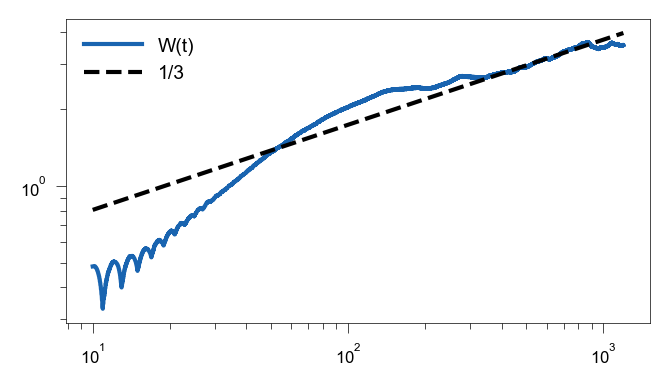

In [73]:
# Assume W_series is already computed and has shape (T,)
start = 1000
W_late = W_average[start:]  # take late-time part
t = np.arange(0, len(W_average)) * dt
t_late = t[start:]
# t = np.arange(start, start + len(W_late))  # corresponding time steps

fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=200)
ax.set_aspect("equal")
plt.loglog(t_late, W_late, label="W(t)", c=dark_blue)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t_late))
ref_line = np.exp(logA) * t_late ** (1 / 3)
plt.loglog(t_late, ref_line, "--", label="1/3", c="k")

# ax.yaxis.set_minor_formatter(
#    LogFormatterSciNotation(
#        base=10,
#        labelOnlyBase=False,
#        minor_thresholds=(np.inf, np.inf),
#    )
# )

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

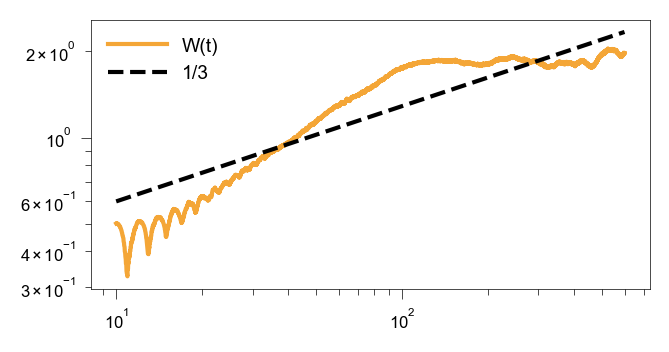

In [74]:
# Assume W_series is already computed and has shape (T,)
start = 1000
W_late = W_average_58[start:]  # take late-time part
t = np.arange(0, len(W_average_58)) * dt
t_late = t[start:]
# t = np.arange(start, start + len(W_late))  # corresponding time steps

fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=200)
ax.set_aspect("equal")
plt.loglog(t_late, W_late, label="W(t)", c=orange)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t_late))
ref_line = np.exp(logA) * t_late ** (1 / 3)
plt.loglog(t_late, ref_line, "--", label="1/3", c="k")

# ax.yaxis.set_minor_formatter(
#    LogFormatterSciNotation(
#        base=10,
#        labelOnlyBase=False,
#        minor_thresholds=(np.inf, np.inf),
#    )
# )

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

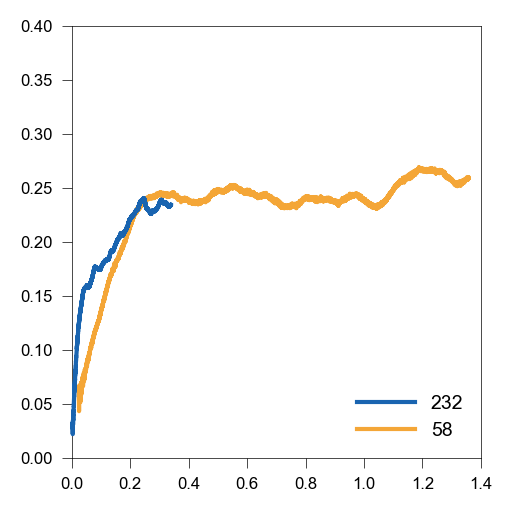

In [75]:
fig, ax = plt.subplots(figsize=(6 * params.cm, 6 * params.cm), dpi=200)
## Assume W_series is already computed and has shape (T,)
start = 1000
# n_cars = 232

# W_FV = W_average[start:] / (n_cars ** (1 / 2))
# t_average = np.arange(0, len(W_average)) * dt
# t_FV = t_average[start:] / (n_cars ** (3 / 2))
# plt.plot(t_FV, W_FV, c="k")
# n_cars = 22
# W_FV22 = W_average_22[start:] / (n_cars ** (1 / 2))
# t_22 = arange(0, len(W_average_22)) * dt
# t_FV22 = t_22[start:] / (n_cars ** (3 / 2))
# plt.plot(t_FV22, W_FV22, c=orange)
# n_cars = 21
# W_FV21 = W_average_21[start:] / (n_cars ** (1 / 2))
# t_21 = arange(0, len(W_average_21)) * dt
# t_FV21 = t_21[start:] / (n_cars ** (3 / 2))
# plt.plot(t_FV21, W_FV21, c=vermilion)
n_cars = 232  # params.L
W_FV = W_average[start:] / (n_cars ** (1 / 2))
t_average = arange(0, len(W_average)) * dt
t_FV = t_average[start:] / (n_cars ** (3 / 2))
plt.plot(t_FV, W_FV, c=dark_blue, zorder=100, clip_on=False, label="232")
# W_FV45 = W_average_45[start:] / (n_cars ** (1 / 2))
# t_45 = np.arange(0, len(W_average_45)) * dt
# t_FV45 = t_45[start:] / (n_cars ** (3 / 2))
# plt.plot(t_FV45, W_FV45, c=dark_teal)
n_cars = 58
W_FV58 = W_average_58[start:] / (n_cars ** (1 / 2))
t_58 = np.arange(0, len(W_average_58)) * dt
t_FV58 = t_58[start:] / (n_cars ** (3 / 2))
plt.plot(t_FV58, W_FV58, c=orange, label="58")
ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=4,
)
ax.set_xlim(0, 1.4)
ax.set_ylim(0.0, 0.4)
plt.tight_layout(pad=0)
plt.show()

In [110]:
import os
from pNeuma_simulator.animations import ring
import matplotlib.animation as animation
from IPython.display import HTML

In [111]:
def animate_ring(i, item, ax, fig):
    fig.tight_layout(pad=0)
    ax.clear()
    ring(i, n_cars, item, ax)
    ax.axvspan(-params.L / 2.0, params.L / 2.0, facecolor=grey, zorder=-1)
    ax.set_xlim(-200, 200)

In [91]:
## Create the animation
# item = l_agents
# step = 4
# fig, ax = plt.subplots(figsize=(14.7 * params.cm, 2.5 * params.cm), dpi=300)
# start = len(l_agents) - 1
# end = len(l_agents)
# ani_ring = animation.FuncAnimation(
#    fig,
#    animate_ring,  # type: ignore
#    frames=range(start, end, step),  # type: ignore
#    fargs=(
#        item,
#        ax,
#        fig,
#    ),
# )
# print(start)

In [92]:
# Save the animation as an HTML video
# ani_ring_html = ani_ring.to_jshtml()

In [93]:
# HTML(ani_ring_html)

In [94]:
path = "./output/movies/"
os.makedirs(path, exist_ok=True)
# file = rf"{path}demo_long.gif"
file = rf"{path}demo_long.mp4"
# writergif = animation.PillowWriter(fps=25)
# ani_ring.save(file, writer=writergif)
# ani_ring.save(file, writer="ffmpeg", fps=25)